In [60]:
import pandas as pd

train_df = pd.read_csv('data/train.csv')

train_df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [61]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [62]:
train_df.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [63]:
train_df['date'] = pd.to_datetime(train_df['date'])
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


In [64]:
# Load the stores data
stores_df = pd.read_csv('data/stores.csv')

# Display a preview
print("--- Stores Data Head ---")
display(stores_df.head())

# Display the summary
print("\n--- Stores Info Summary ---")
stores_df.info()

--- Stores Data Head ---


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4



--- Stores Info Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB


In [65]:
# Load the oil price data
oil_df = pd.read_csv('data/oil.csv')

# Display a preview
print("--- Oil Price Data Head ---")
display(oil_df.head())

# Display the summary
print("\n--- Oil Price Info Summary ---")
oil_df.info()

--- Oil Price Data Head ---


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20



--- Oil Price Info Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   object 
 1   dcoilwtico  1175 non-null   float64
dtypes: float64(1), object(1)
memory usage: 19.2+ KB


<Axes: title={'center': 'Daily Oil Price (with Gaps)'}, xlabel='date'>

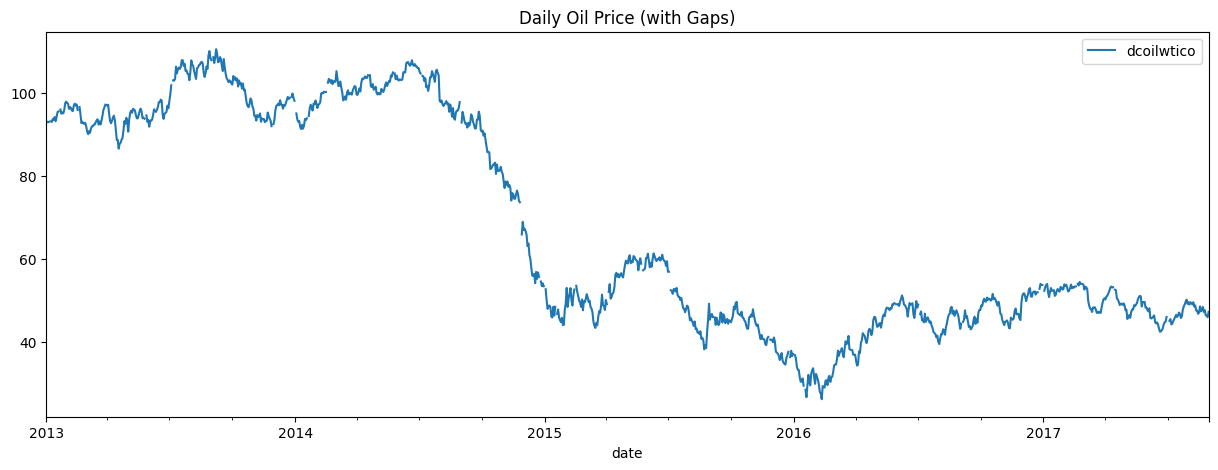

In [66]:
# Convert the 'date' column to a datetime object
oil_df['date'] = pd.to_datetime(oil_df['date'])

# Plot the data to visualize it
oil_df.plot(x='date', y='dcoilwtico', figsize=(15, 5), title='Daily Oil Price (with Gaps)')

In [67]:
# The new, preferred way
oil_df['dcoilwtico'] = oil_df['dcoilwtico'].ffill()
oil_df['dcoilwtico'] = oil_df['dcoilwtico'].bfill()

# Verify that the gaps are filled
print("--- Oil Price Info Summary (After Filling) ---")
oil_df.info()

--- Oil Price Info Summary (After Filling) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1218 non-null   datetime64[ns]
 1   dcoilwtico  1218 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 19.2 KB


In [68]:
# Load the holidays and events data
holidays_df = pd.read_csv('data/holidays_events.csv')

# Display a preview
print("--- Holidays Data Head ---")
display(holidays_df.head())

# Check for unique values in each column
print("\n--- Unique Values in Holidays Data ---")
display(holidays_df.nunique())

--- Holidays Data Head ---


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False



--- Unique Values in Holidays Data ---


date           312
type             6
locale           3
locale_name     24
description    103
transferred      2
dtype: int64

In [69]:
# Load the transactions data
transactions_df = pd.read_csv('data/transactions.csv')

# Convert the 'date' column to datetime
transactions_df['date'] = pd.to_datetime(transactions_df['date'])

# Display a preview
print("--- Transactions Data Head ---")
display(transactions_df.head())

# Display the summary
print("\n--- Transactions Info Summary ---")
transactions_df.info()

--- Transactions Data Head ---


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922



--- Transactions Info Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          83488 non-null  datetime64[ns]
 1   store_nbr     83488 non-null  int64         
 2   transactions  83488 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 1.9 MB


In [70]:
# Create a copy of train_df to work with, which is a good practice
df = train_df.copy()

# Merge the stores information
# We are joining on the common 'store_nbr' column
df = pd.merge(df, stores_df, on='store_nbr', how='left')

# Display a preview to see the new columns
print("--- Merged DataFrame Head ---")
display(df.head())

# Check the info summary
print("\n--- Merged DataFrame Info ---")
df.info()

--- Merged DataFrame Head ---


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13



--- Merged DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 10 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
 6   city         object        
 7   state        object        
 8   type         object        
 9   cluster      int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(4)
memory usage: 228.9+ MB


In [71]:
# Merge the daily oil price data
# We are joining on the common 'date' column
df = pd.merge(df, oil_df, on='date', how='left')

# Display a preview to see the new oil price column
print("--- DataFrame Head after merging Oil Data ---")
display(df.head())

# Check the info summary
print("\n--- DataFrame Info after merging Oil Data ---")
df.info()

--- DataFrame Head after merging Oil Data ---


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,dcoilwtico
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,93.14
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,93.14
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,93.14
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,93.14
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,93.14



--- DataFrame Info after merging Oil Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 11 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
 6   city         object        
 7   state        object        
 8   type         object        
 9   cluster      int64         
 10  dcoilwtico   float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(4)
memory usage: 251.8+ MB


In [72]:
# Merge the transactions data
# This is a multi-key join on both 'date' and 'store_nbr'
df = pd.merge(df, transactions_df, on=['date', 'store_nbr'], how='left')

# Display a preview
print("--- DataFrame Head after merging Transactions ---")
display(df.head())

# Check the info summary
print("\n--- DataFrame Info after merging Transactions ---")
df.info()

--- DataFrame Head after merging Transactions ---


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,dcoilwtico,transactions
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,93.14,NaN
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,93.14,NaN
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,93.14,NaN
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,93.14,NaN
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,93.14,NaN



--- DataFrame Info after merging Transactions ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 12 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            int64         
 1   date          datetime64[ns]
 2   store_nbr     int64         
 3   family        object        
 4   sales         float64       
 5   onpromotion   int64         
 6   city          object        
 7   state         object        
 8   type          object        
 9   cluster       int64         
 10  dcoilwtico    float64       
 11  transactions  float64       
dtypes: datetime64[ns](1), float64(3), int64(4), object(4)
memory usage: 274.7+ MB


In [73]:
# Convert the 'date' column in holidays_df to the datetime type
holidays_df['date'] = pd.to_datetime(holidays_df['date'])

# Rename the 'type' column in holidays_df to avoid a name conflict
holidays_df.rename(columns={'type': 'holiday_type'}, inplace=True)

# Merge the holidays data on the 'date' column
df = pd.merge(df, holidays_df, on='date', how='left')

# Display a preview
print("--- Final Merged DataFrame Head ---")
display(df.head())

# Check the final info summary
print("\n--- Final Merged DataFrame Info ---")
df.info()

--- Final Merged DataFrame Head ---


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,dcoilwtico,transactions,holiday_type,locale,locale_name,description,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,93.14,NaN,Holiday,National,Ecuador,Primer dia del ano,False
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,93.14,NaN,Holiday,National,Ecuador,Primer dia del ano,False
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,93.14,NaN,Holiday,National,Ecuador,Primer dia del ano,False
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,93.14,NaN,Holiday,National,Ecuador,Primer dia del ano,False
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,93.14,NaN,Holiday,National,Ecuador,Primer dia del ano,False



--- Final Merged DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3054348 entries, 0 to 3054347
Data columns (total 17 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            int64         
 1   date          datetime64[ns]
 2   store_nbr     int64         
 3   family        object        
 4   sales         float64       
 5   onpromotion   int64         
 6   city          object        
 7   state         object        
 8   type          object        
 9   cluster       int64         
 10  dcoilwtico    float64       
 11  transactions  float64       
 12  holiday_type  object        
 13  locale        object        
 14  locale_name   object        
 15  description   object        
 16  transferred   object        
dtypes: datetime64[ns](1), float64(3), int64(4), object(9)
memory usage: 396.1+ MB


In [74]:
# Fill missing values in the 'transactions' column with 0
df['transactions'] = df['transactions'].fillna(0)

# Verify that the missing values are gone
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3054348 entries, 0 to 3054347
Data columns (total 17 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            int64         
 1   date          datetime64[ns]
 2   store_nbr     int64         
 3   family        object        
 4   sales         float64       
 5   onpromotion   int64         
 6   city          object        
 7   state         object        
 8   type          object        
 9   cluster       int64         
 10  dcoilwtico    float64       
 11  transactions  float64       
 12  holiday_type  object        
 13  locale        object        
 14  locale_name   object        
 15  description   object        
 16  transferred   object        
dtypes: datetime64[ns](1), float64(3), int64(4), object(9)
memory usage: 396.1+ MB


In [75]:
# Define the columns related to holidays
holiday_cols = ['holiday_type', 'locale', 'locale_name', 'description', 'transferred']

# Fill NaN values in these columns with "No Holiday"
df[holiday_cols] = df[holiday_cols].fillna("No Holiday")

# Verify the changes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3054348 entries, 0 to 3054347
Data columns (total 17 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            int64         
 1   date          datetime64[ns]
 2   store_nbr     int64         
 3   family        object        
 4   sales         float64       
 5   onpromotion   int64         
 6   city          object        
 7   state         object        
 8   type          object        
 9   cluster       int64         
 10  dcoilwtico    float64       
 11  transactions  float64       
 12  holiday_type  object        
 13  locale        object        
 14  locale_name   object        
 15  description   object        
 16  transferred   object        
dtypes: datetime64[ns](1), float64(3), int64(4), object(9)
memory usage: 396.1+ MB


In [76]:
# Extract date components using the .dt accessor
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek # Note: Monday=0, Sunday=6
df['day_of_year'] = df['date'].dt.dayofyear

# Display a preview to see the new date-based features
df.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,...,transactions,holiday_type,locale,locale_name,description,transferred,year,month,day_of_week,day_of_year
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,...,0.0,Holiday,National,Ecuador,Primer dia del ano,False,2013,1,1,1
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,...,0.0,Holiday,National,Ecuador,Primer dia del ano,False,2013,1,1,1
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,...,0.0,Holiday,National,Ecuador,Primer dia del ano,False,2013,1,1,1
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,...,0.0,Holiday,National,Ecuador,Primer dia del ano,False,2013,1,1,1
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,...,0.0,Holiday,National,Ecuador,Primer dia del ano,False,2013,1,1,1


In [77]:
# --- Advanced Feature Engineering ---

# Create a 16-day lag for sales.
# We group by each store/family combination to prevent data leakage.
df['sales_lag_16'] = df.groupby(['store_nbr', 'family'])['sales'].shift(16)

# --- Verification Step ---
# Let's look at one specific store/family to see the result.
# Notice the first 16 values for 'sales_lag_16' are NaN (empty).
display(df[
    (df['store_nbr'] == 1) &
    (df['family'] == 'AUTOMOTIVE')
].head(20))

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,...,holiday_type,locale,locale_name,description,transferred,year,month,day_of_week,day_of_year,sales_lag_16
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,...,Holiday,National,Ecuador,Primer dia del ano,False,2013,1,1,1,NaN
1782,1782,2013-01-02,1,AUTOMOTIVE,2.0,0,Quito,Pichincha,D,13,...,No Holiday,No Holiday,No Holiday,No Holiday,No Holiday,2013,1,2,2,NaN
3564,3564,2013-01-03,1,AUTOMOTIVE,3.0,0,Quito,Pichincha,D,13,...,No Holiday,No Holiday,No Holiday,No Holiday,No Holiday,2013,1,3,3,NaN
5346,5346,2013-01-04,1,AUTOMOTIVE,3.0,0,Quito,Pichincha,D,13,...,No Holiday,No Holiday,No Holiday,No Holiday,No Holiday,2013,1,4,4,NaN
7128,7128,2013-01-05,1,AUTOMOTIVE,5.0,0,Quito,Pichincha,D,13,...,Work Day,National,Ecuador,Recupero puente Navidad,False,2013,1,5,5,NaN
8910,8910,2013-01-06,1,AUTOMOTIVE,2.0,0,Quito,Pichincha,D,13,...,No Holiday,No Holiday,No Holiday,No Holiday,No Holiday,2013,1,6,6,NaN
10692,10692,2013-01-07,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,...,No Holiday,No Holiday,No Holiday,No Holiday,No Holiday,2013,1,0,7,NaN
12474,12474,2013-01-08,1,AUTOMOTIVE,2.0,0,Quito,Pichincha,D,13,...,No Holiday,No Holiday,No Holiday,No Holiday,No Holiday,2013,1,1,8,NaN
14256,14256,2013-01-09,1,AUTOMOTIVE,2.0,0,Quito,Pichincha,D,13,...,No Holiday,No Holiday,No Holiday,No Holiday,No Holiday,2013,1,2,9,NaN
16038,16038,2013-01-10,1,AUTOMOTIVE,2.0,0,Quito,Pichincha,D,13,...,No Holiday,No Holiday,No Holiday,No Holiday,No Holiday,2013,1,3,10,NaN


In [78]:
# Fill the NaNs created by the lag feature with 0
df['sales_lag_16'] = df['sales_lag_16'].fillna(0)

# --- Create Rolling Window Features ---
# Calculate the 7-day and 28-day rolling average of sales for each group
df['sales_rolling_mean_7'] = df.groupby(['store_nbr', 'family'])['sales'].rolling(window=7).mean().reset_index(level=[0,1], drop=True)
df['sales_rolling_mean_28'] = df.groupby(['store_nbr', 'family'])['sales'].rolling(window=28).mean().reset_index(level=[0,1], drop=True)

# Fill the NaNs created by the rolling window operation with 0
df['sales_rolling_mean_7'] = df['sales_rolling_mean_7'].fillna(0)
df['sales_rolling_mean_28'] = df['sales_rolling_mean_28'].fillna(0)

# --- Verification Step ---
print("New rolling average features created:")
display(df.head())

New rolling average features created:


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,...,locale_name,description,transferred,year,month,day_of_week,day_of_year,sales_lag_16,sales_rolling_mean_7,sales_rolling_mean_28
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,...,Ecuador,Primer dia del ano,False,2013,1,1,1,0.0,0.0,0.0
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,...,Ecuador,Primer dia del ano,False,2013,1,1,1,0.0,0.0,0.0
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,...,Ecuador,Primer dia del ano,False,2013,1,1,1,0.0,0.0,0.0
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,...,Ecuador,Primer dia del ano,False,2013,1,1,1,0.0,0.0,0.0
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,...,Ecuador,Primer dia del ano,False,2013,1,1,1,0.0,0.0,0.0


In [79]:
# Select all columns that are of 'object' type and convert them
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category').cat.codes

# Display a preview to see the encoded columns
print("--- DataFrame after Categorical Encoding ---")
display(df.head())

# Check the data types to confirm the change
print("\n--- DataFrame Info after Categorical Encoding ---")
df.info()

--- DataFrame after Categorical Encoding ---


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,...,locale_name,description,transferred,year,month,day_of_week,day_of_year,sales_lag_16,sales_rolling_mean_7,sales_rolling_mean_28
0,0,2013-01-01,1,0,0.0,0,18,12,3,13,...,4,51,0,2013,1,1,1,0.0,0.0,0.0
1,1,2013-01-01,1,1,0.0,0,18,12,3,13,...,4,51,0,2013,1,1,1,0.0,0.0,0.0
2,2,2013-01-01,1,2,0.0,0,18,12,3,13,...,4,51,0,2013,1,1,1,0.0,0.0,0.0
3,3,2013-01-01,1,3,0.0,0,18,12,3,13,...,4,51,0,2013,1,1,1,0.0,0.0,0.0
4,4,2013-01-01,1,4,0.0,0,18,12,3,13,...,4,51,0,2013,1,1,1,0.0,0.0,0.0



--- DataFrame Info after Categorical Encoding ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3054348 entries, 0 to 3054347
Data columns (total 24 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   id                     int64         
 1   date                   datetime64[ns]
 2   store_nbr              int64         
 3   family                 int8          
 4   sales                  float64       
 5   onpromotion            int64         
 6   city                   int8          
 7   state                  int8          
 8   type                   int8          
 9   cluster                int64         
 10  dcoilwtico             float64       
 11  transactions           float64       
 12  holiday_type           int8          
 13  locale                 int8          
 14  locale_name            int8          
 15  description            int8          
 16  transferred            int8          
 17  year          

In [80]:
# Drop the original date and id columns
df.drop(['id', 'date'], axis=1, inplace=True)

# Sort the dataframe by store, family, and time
df.sort_values(by=['store_nbr', 'family', 'year', 'day_of_year'], inplace=True)


# Display a preview of the final, model-ready dataset
print("--- Final Model-Ready DataFrame Head ---")
display(df.head())

# Check the final info
print("\n--- Final Model-Ready DataFrame Info ---")
df.info()

--- Final Model-Ready DataFrame Head ---


,store_nbr,family,sales,onpromotion,city,state,type,cluster,dcoilwtico,transactions,...,locale_name,description,transferred,year,month,day_of_week,day_of_year,sales_lag_16,sales_rolling_mean_7,sales_rolling_mean_28
0,1,0,0.0,0,18,12,3,13,93.14,0.0,...,4,51,0,2013,1,1,1,0.0,0.0,0.0
1782,1,0,2.0,0,18,12,3,13,93.14,2111.0,...,16,49,2,2013,1,2,2,0.0,0.0,0.0
3564,1,0,3.0,0,18,12,3,13,92.97,1833.0,...,16,49,2,2013,1,3,3,0.0,0.0,0.0
5346,1,0,3.0,0,18,12,3,13,93.12,1863.0,...,16,49,2,2013,1,4,4,0.0,0.0,0.0
7128,1,0,5.0,0,18,12,3,13,NaN,1509.0,...,4,63,0,2013,1,5,5,0.0,0.0,0.0



--- Final Model-Ready DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 3054348 entries, 0 to 3054215
Data columns (total 22 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   store_nbr              int64  
 1   family                 int8   
 2   sales                  float64
 3   onpromotion            int64  
 4   city                   int8   
 5   state                  int8   
 6   type                   int8   
 7   cluster                int64  
 8   dcoilwtico             float64
 9   transactions           float64
 10  holiday_type           int8   
 11  locale                 int8   
 12  locale_name            int8   
 13  description            int8   
 14  transferred            int8   
 15  year                   int32  
 16  month                  int32  
 17  day_of_week            int32  
 18  day_of_year            int32  
 19  sales_lag_16           float64
 20  sales_rolling_mean_7   float64
 21  sales_rolling_mea

In [81]:
# The target variable is 'sales'
y = df['sales']

# The features are all columns EXCEPT 'sales'
X = df.drop('sales', axis=1)

# Verify the shapes of our new DataFrames
print(f"Shape of our features (X): {X.shape}")
print(f"Shape of our target (y): {y.shape}")

Shape of our features (X): (3054348, 21)
Shape of our target (y): (3054348,)


In [82]:
# The Kaggle competition asks for a 16-day forecast,
# so we'll use the last 16 days of data as our validation set.
# Number of rows per day = 54 stores * 33 product families
rows_per_day = 54 * 33
validation_size = 16 * rows_per_day

# Split the features (X) and target (y)
X_train = X[:-validation_size]
y_train = y[:-validation_size]
X_val = X[-validation_size:]
y_val = y[-validation_size:]

# Verify the shapes of our new sets
print(f"Training Features Shape: {X_train.shape}")
print(f"Training Target Shape: {y_train.shape}")
print(f"Validation Features Shape: {X_val.shape}")
print(f"Validation Target Shape: {y_val.shape}")

Training Features Shape: (3025836, 21)
Training Target Shape: (3025836,)
Validation Features Shape: (28512, 21)
Validation Target Shape: (28512,)


In [83]:
import lightgbm as lgb

# Create an instance of the LightGBM Regressor model
# random_state=42 ensures our results are reproducible
model = lgb.LGBMRegressor(random_state=42)

# Train (fit) the model on our training data
print("Training the LightGBM model... (this may take a minute)")
model.fit(X_train, y_train)

print("Model training complete! 🎉")

Training the LightGBM model... (this may take a minute)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.119323 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2044
[LightGBM] [Info] Number of data points in the train set: 3025836, number of used features: 21
[LightGBM] [Info] Start training from score 361.905347
Model training complete! 🎉


In [84]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Use the trained model to make predictions on the validation set
print("Making predictions on the validation data...")
y_pred = model.predict(X_val)

# Calculate the Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print(f"\nValidation RMSE: {rmse:.4f}")

Making predictions on the validation data...

Validation RMSE: 31.1672


Calculating SHAP values...
Calculation complete.
Generating summary plot...


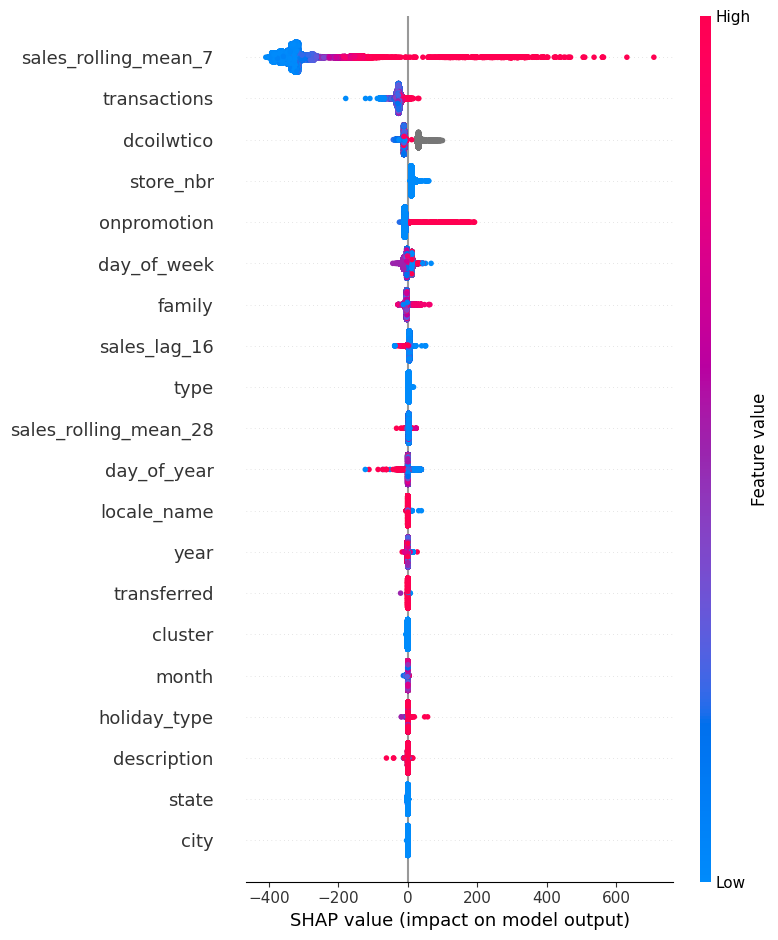

In [85]:
import shap

# Create a SHAP explainer object for our model
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for our validation data
# This can take a moment to compute
print("Calculating SHAP values...")
shap_values = explainer.shap_values(X_val)
print("Calculation complete.")

# Create the summary plot to visualize feature importance
print("Generating summary plot...")
shap.summary_plot(shap_values, X_val)

In [86]:
import joblib

# Save the trained model to a file
joblib.dump(model, 'lgbm_model.joblib')

# Save the validation features (for SHAP plots)
joblib.dump(X_val, 'X_val.joblib')

print("Model and validation data saved successfully!")

Model and validation data saved successfully!


In [87]:
import joblib

# Save the validation target data
joblib.dump(y_val, 'y_val.joblib')

print("Validation target (y_val) saved successfully!")

Validation target (y_val) saved successfully!
